In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path("../data/processed/market_stress_v0.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["date"])

print(df.shape)
print(df["date"].min(), df["date"].max())
df.head()

(7830, 22)
1993-03-01 00:00:00 2024-04-08 00:00:00


,date,spy_open,spy_high,spy_low,spy_close,spy_adj_close,spy_volume,vix_close,spy_log_return,spy_return,...,spy_dollar_volume,rv_5d,rv_10d,rv_20d,spy_drawdown_20d,vix_change,vix_pct_change,vix_ma_5d,future_rv_5d,future_high_vol_label
0,1993-03-01,44.5625,44.5625,44.2188,44.2813,24.9614,66500,13.60,-0.002820,-0.002816,...,1659933.10,0.095883,0.154578,0.124670,-0.015974,0.44,0.033435,14.056,0.185784,0
1,1993-03-02,44.3125,44.9375,44.2500,44.9375,25.3314,182400,12.49,0.014714,0.014823,...,4620447.36,0.121783,0.093381,0.132782,-0.001388,-1.11,-0.081618,13.546,0.179954,0
2,1993-03-03,45.0000,45.1563,44.9375,45.1250,25.4370,280100,13.13,0.004160,0.004169,...,7124903.70,0.103964,0.090640,0.133253,0.000000,0.64,0.051241,13.228,0.179646,0
3,1993-03-04,45.1875,45.1875,44.8750,44.8750,25.2961,89500,13.44,-0.005555,-0.005539,...,2264000.95,0.124553,0.100158,0.130002,-0.005539,0.31,0.023610,13.164,0.172689,0
4,1993-03-05,44.9375,45.1250,44.7188,44.7500,25.2257,40000,14.08,-0.002787,-0.002783,...,1009028.00,0.130057,0.104702,0.129433,-0.008307,0.64,0.047619,13.348,0.195574,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7830 entries, 0 to 7829
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   7830 non-null   datetime64[us]
 1   spy_open               7830 non-null   float64       
 2   spy_high               7830 non-null   float64       
 3   spy_low                7830 non-null   float64       
 4   spy_close              7830 non-null   float64       
 5   spy_adj_close          7830 non-null   float64       
 6   spy_volume             7830 non-null   int64         
 7   vix_close              7830 non-null   float64       
 8   spy_log_return         7830 non-null   float64       
 9   spy_return             7830 non-null   float64       
 10  spy_abs_return         7830 non-null   float64       
 11  spy_range              7830 non-null   float64       
 12  spy_dollar_volume      7830 non-null   float64       
 13  rv_5d         

In [4]:
df.isna().sum().sort_values(ascending=False)

date                     0
spy_open                 0
future_rv_5d             0
vix_ma_5d                0
vix_pct_change           0
vix_change               0
spy_drawdown_20d         0
rv_20d                   0
rv_10d                   0
rv_5d                    0
spy_dollar_volume        0
spy_range                0
spy_abs_return           0
spy_return               0
spy_log_return           0
vix_close                0
spy_volume               0
spy_adj_close            0
spy_close                0
spy_low                  0
spy_high                 0
future_high_vol_label    0
dtype: int64

In [5]:
df["future_high_vol_label"].value_counts(normalize=True)

future_high_vol_label
0    0.799489
1    0.200511
Name: proportion, dtype: float64

In [12]:


# 1. sorted dates
assert df["date"].is_monotonic_increasing

# 2. duplicate dates
print("duplicate dates:", df["date"].duplicated().sum())

# 3. calendar gaps between consecutive trading rows
gaps = df["date"].diff().dt.days
print(gaps.value_counts().sort_index().tail(20))

# 4. suspicious large gaps
print(df.loc[gaps > 5, ["date"]].assign(prev_date=df["date"].shift(1)).head(20))

duplicate dates: 0
date
1.0    6136
2.0      69
3.0    1414
4.0     207
5.0       2
7.0       1
Name: count, dtype: int64
           date  prev_date
2152 2001-09-17 2001-09-10


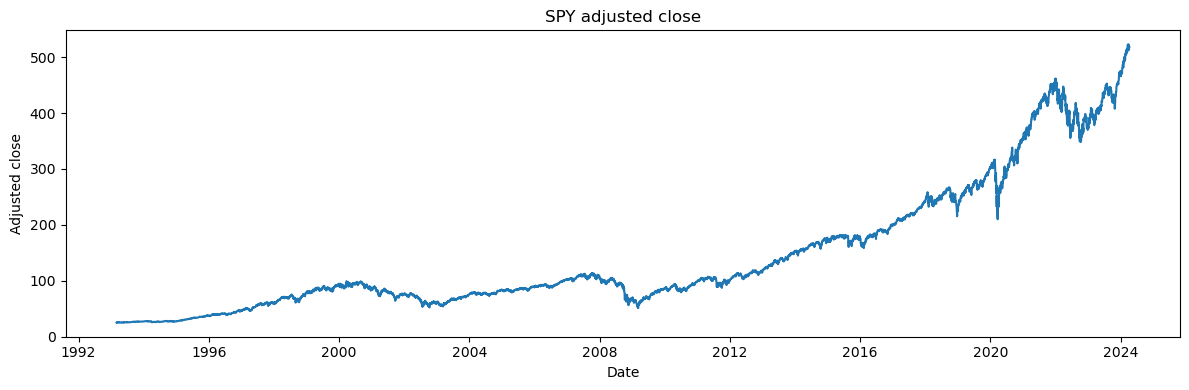

In [ ]:
# plot SPY adjusted close

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["spy_adj_close"])
plt.title("SPY adjusted close")
plt.xlabel("Date")
plt.ylabel("Adjusted close")
plt.tight_layout()
plt.show()

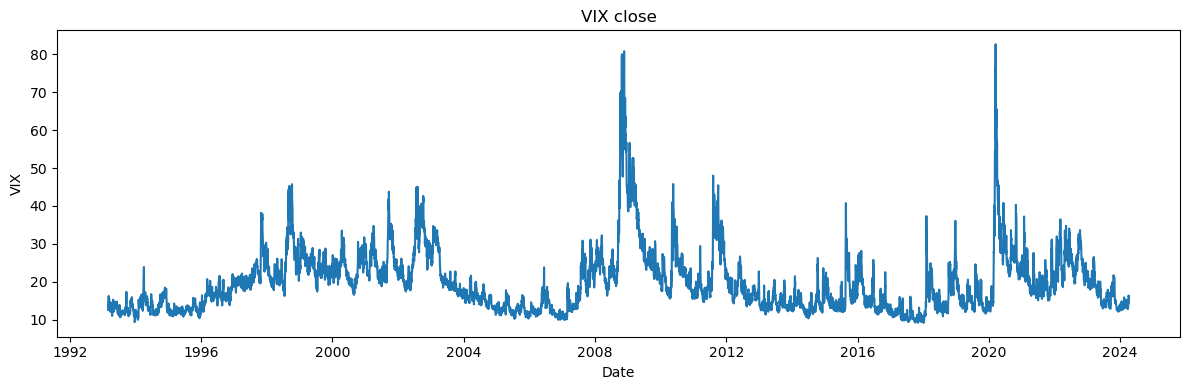

In [ ]:
# plot VIX

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["vix_close"])
plt.title("VIX close")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.tight_layout()
plt.show()

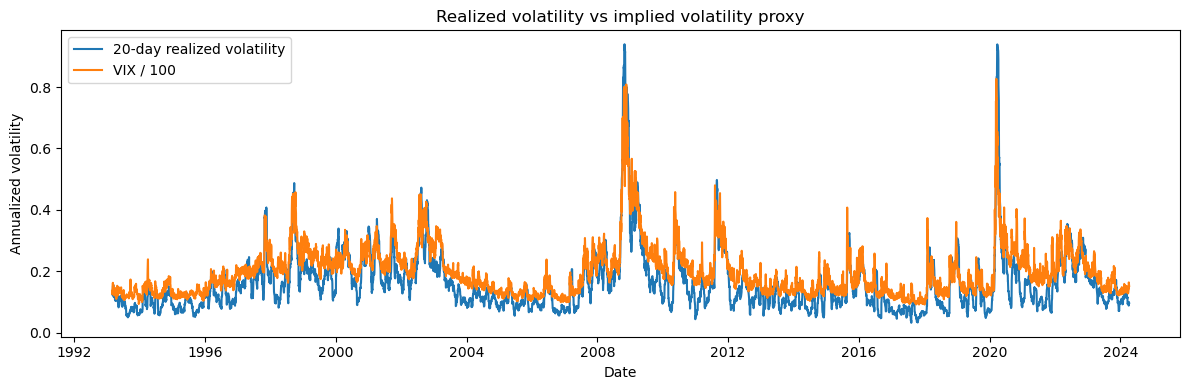

In [ ]:
# realized volatility vs VIX

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["rv_20d"], label="20-day realized volatility")
plt.plot(df["date"], df["vix_close"] / 100, label="VIX / 100")
plt.title("Realized volatility vs implied volatility proxy")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.legend()
plt.tight_layout()
plt.show()

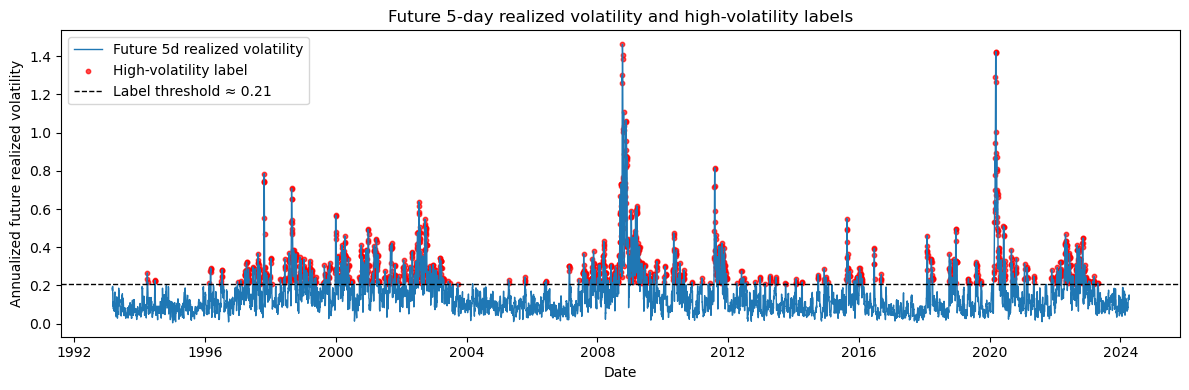

In [13]:
threshold = df.loc[df["future_high_vol_label"] == 1, "future_rv_5d"].min()

plt.figure(figsize=(12, 4))
plt.plot(
    df["date"],
    df["future_rv_5d"],
    label="Future 5d realized volatility",
    linewidth=1,
)
plt.scatter(
    df.loc[df["future_high_vol_label"] == 1, "date"],
    df.loc[df["future_high_vol_label"] == 1, "future_rv_5d"],
    s=10,
    color="red",
    alpha=0.7,
    label="High-volatility label",
)
plt.axhline(
    threshold,
    linestyle="--",
    linewidth=1,
    color="black",
    label=f"Label threshold ≈ {threshold:.2f}",
)
plt.title("Future 5-day realized volatility and high-volatility labels")
plt.xlabel("Date")
plt.ylabel("Annualized future realized volatility")
plt.legend()
plt.tight_layout()
plt.show()

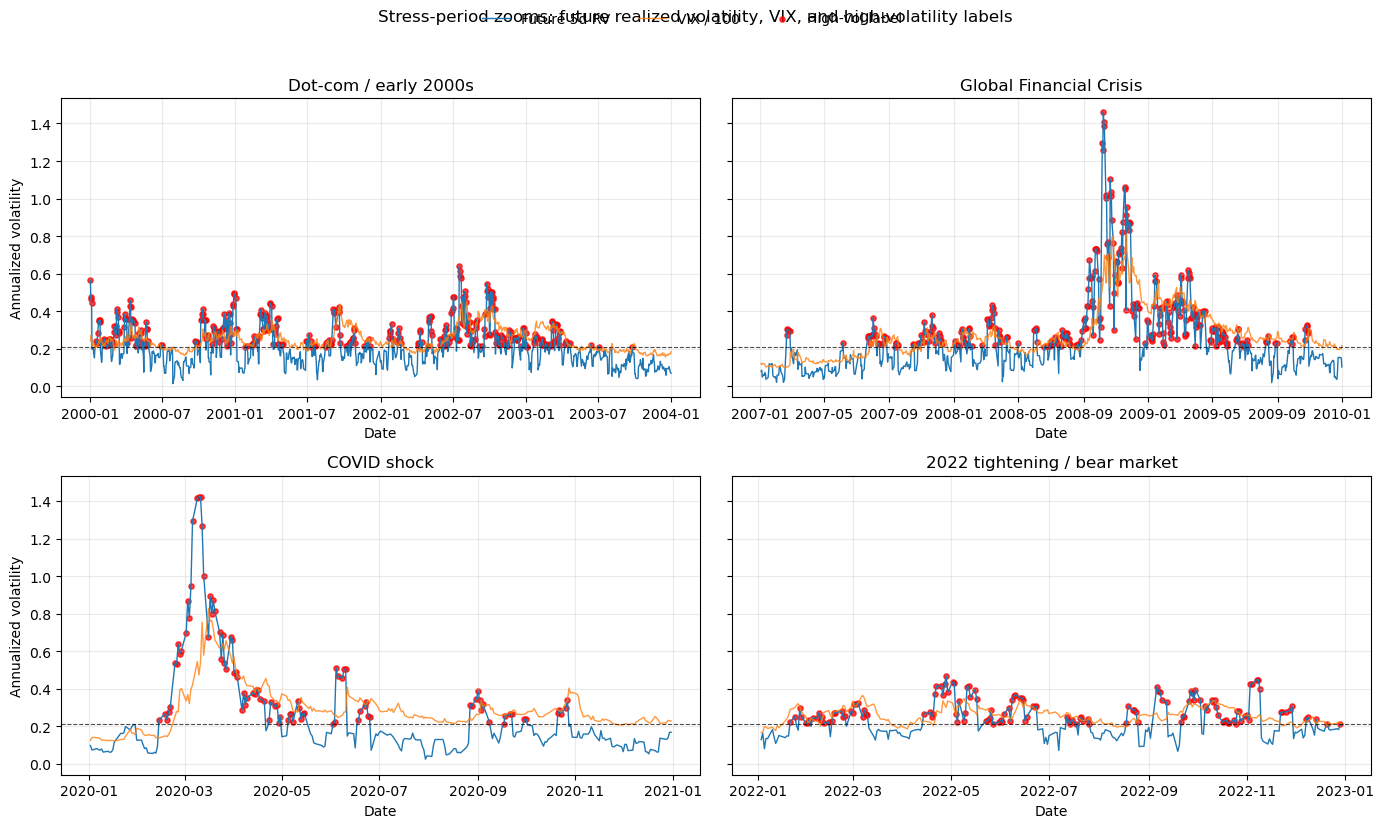

In [14]:
# Crisis-period zooms: 2x2 layout

periods = {
    "Dot-com / early 2000s": ("2000-01-01", "2003-12-31"),
    "Global Financial Crisis": ("2007-01-01", "2009-12-31"),
    "COVID shock": ("2020-01-01", "2020-12-31"),
    "2022 tightening / bear market": ("2022-01-01", "2022-12-31"),
}

threshold = df.loc[df["future_high_vol_label"] == 1, "future_rv_5d"].min()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax, (name, (start, end)) in zip(axes, periods.items()):
    sub = df[(df["date"] >= start) & (df["date"] <= end)]

    ax.plot(
        sub["date"],
        sub["future_rv_5d"],
        label="Future 5d RV",
        linewidth=1,
    )
    ax.plot(
        sub["date"],
        sub["vix_close"] / 100,
        label="VIX / 100",
        linewidth=1,
        alpha=0.8,
    )
    ax.scatter(
        sub.loc[sub["future_high_vol_label"] == 1, "date"],
        sub.loc[sub["future_high_vol_label"] == 1, "future_rv_5d"],
        s=14,
        color="red",
        alpha=0.75,
        label="High-vol label",
    )
    ax.axhline(
        threshold,
        linestyle="--",
        linewidth=0.8,
        color="black",
        alpha=0.7,
    )

    ax.set_title(name)
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Annualized volatility")
axes[2].set_ylabel("Annualized volatility")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

fig.suptitle("Stress-period zooms: future realized volatility, VIX, and high-volatility labels", y=1.03)
fig.tight_layout()
plt.show()

## Exploration conclusion

The v0 dataset is usable for the first modeling milestone. SPY provides realized market behavior through adjusted-close returns, realized volatility, intraday range, drawdown, and volume/activity proxies. VIX provides an option-implied volatility/stress signal. The constructed `future_high_vol_label` marks the top 20% of future 5-day realized-volatility periods and clusters around recognizable stress regimes rather than appearing random.

Caveats:
- The v0 label is directionless: it detects high volatility, not specifically downside crash stress.
- The current label threshold is provisional for exploration; modeling code must recompute thresholds using the training split only.
- VIX is informative but not a pure forecast because it includes risk premium and option-market demand.